In [1]:
## importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

In [2]:
df = pd.read_excel('finalforms.xlsx')

In [3]:
# pd.set_option('display.max_columns', None)
pd.set_option('display.max_columns',None)

In [4]:
print(df.shape)
# print(df.head())
df.columns[18]

(62, 104)


'Upon arrival, I prefer to interact with a human staff member rather than a digital system.'

In [5]:
# Clean column names: strip spaces, replace line breaks, compress spaces
df.columns = (
    df.columns
    .str.replace("\n", " ", regex=False)
    .str.replace("\r", " ", regex=False)
    .str.strip()
    .str.replace(" +", " ", regex=True)
)



In [6]:
pd.set_option('display.max_columns',None)

In [7]:
df

,ID,Start time,Completion time,Email,Name,Last modified time,I consent to processing my personal data gathered during the research in the way described in the information sheet.,I consent to retaining research data gathered from me and using this for future research in the field of Computer Science and Mathematics in which recognized ethical standards for scientific resea...,"I consent to making research data gathered from me available in anonymized form via a repository, namely 4TU.ResearchData repository for the purpose of retaining the data and using it for future ...",Do you consent to participate in this study?,Date,"When visiting restaurants, which types of systems have you used? (Select all that applies)",2,Human waiter,Digital screen (tablet / kiosk / QR code / app),Voice-based system (robot / assistant),"Please describe, in your own words, what aspects of a restaurant visit such as entering, being seated, dining, or paying make the overall experience feel smooth or frustrating.","When dining at a restaurant, what is your preferred way to place an order?","Upon arrival, I prefer to interact with a human staff member rather than a digital system.",It feels easier to know what to do when a person guides me upon arrival,Personal interaction with staff at arrival makes the dining experience feel more genuine,It is easier to understand menu items when a person explains them,I like when a staff member helps me explore the menu or suggests dishes,I trust human staff more than a digital system to provide accurate menu information,I enjoy hearing about dishes from a person rather than reading them on a screen,"When a digital system fails, having human staff as a fallback makes me feel supported",I like having the option of human assistance while using a digital system,It is easier to explain my dietary preferences or special needs to a person,It is easier to change or adjust my order when interacting with human staff,I feel reassured when a person confirms my customized order verbally,It is easier to get assistance during the meal from human staff than from a digital system,Human staff are better at judging the right time to bring the next course than digital systems,I feel more comfortable communicating personal or dietary needs to a person than through a digital device,Being checked on by human staff during the meal makes the experience feel more personal,It is easier to ask follow-up questions about dishes when speaking to a person,I trust human staff to handle payments more accurately than a digital system,It is easier to clarify billing or payment questions with a person,"If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",It is easier to understand the bill when a person explains what I am paying for,Having a person handle payment makes me feel more confident and reassured about the transaction,I feel more in control of my payment when interacting with a person rather than a digital system,I rarely need help from staff when using digital systems,It is easy to know how to begin ordering using a digital system,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions,What are your main concerns or frustrations when using such digital systems?,I would feel comfortable speaking to a voice-based system in a restaurant,Being greeted or guided by a voice-enabled robot would feel pleasant and welcoming,"Browsing or selecting menu items by speak

In [8]:
likert_cols = [
"It is easy to share my seating preferences when booking digitally",
"It is easy to customize my order when using a digital system",
"If something goes wrong, I can easily correct or seek help through the system",
"Wait time for table",
"Wait time for food (meals)",
"Wait time for bill",
"I feel confident about what to do next when ordering through a digital menu",
"I feel confident finding dishes that fit my diet or allergies",
"I feel confident making payments through a digital system",
"I feel comfortable paying without staff involvement",
"I prefer to ask staff only for special or complex requests rather than routine actions"
]


In [9]:
LIKERT_ORDER = {
    "strongly disagree": 1,
    "disagree": 2,
    "slightly disagree": 3,
    "slightly agree": 4,
    "agree": 5,
    "strongly agree": 6,
}


In [10]:
[col for col in likert_cols if col not in df.columns]


[]

In [11]:
# this is used to check if the spacing is consistent

vals = list(LIKERT_ORDER .values())
diffs = np.diff(vals)

np.all(diffs == diffs[0])

True

In [12]:
# print(df.columns.tolist())


In [13]:
#[col for col in likert_cols if col not in df.columns]

df[likert_cols] = df[likert_cols].apply(lambda col: col.str.lower())


In [14]:
# 2. Make column names clean (optional but recommended)
df.columns = df.columns.str.strip().str.rstrip(".")

# 3. Check which names in likert_cols are incorrect
not_in_df = [col for col in likert_cols if col not in df.columns]
print("Columns not found:", not_in_df)

# 4. Convert all Likert columns to lowercase text
df[likert_cols] = df[likert_cols].apply(lambda col: col.str.lower())

# 5. Map text → numeric values
df[likert_cols] = df[likert_cols].replace(LIKERT_ORDER)

# 6. Run Spearman correlation matrix
corr = df[likert_cols].corr(method="spearman")

corr

Columns not found: []


,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions
It is easy to share my seating preferences when booking digitally,1.000000,0.618356,0.174002,-0.281427,0.161829,-0.167323,0.289528,-0.003396,0.288344,0.167362,0.103442
It is easy to customize my order when using a digital system,0.618356,1.000000,0.307210,-0.396466,-0.028756,-0.456497,0.115177,0.309691,0.192623,0.067676,-0.071934
"If something goes wrong, I can easily correct or seek help through the system",0.174002,0.307210,1.000000,-0.175584,0.132157,-0.210773,0.153601,0.091744,-0.200042,-0.231509,-0.017454
Wait time for table,-0.281427,-0.396466,-0.175584,1.000000,0.313566,0.582315,0.045696,0.051946,-0.063835,-0.196060,0.175814
Wait time for food (meals),0.161829,-0.028756,0.132157,0.313566,1.000000,0.125025,0.252589,-0.038611,0.156503,0.111490,0.146507
Wait time for bill,-0.167323,-0.456497,-0.210773,0.582315,0.125025,1.000000,0.051799,-0.181970,-0.227857,-0.207037,0.074142
I feel confident about what to do next when ordering through a digital menu,0.289528,0.115177,0.153601,0.045696,0.252589,0.051799,1.000000,0.370723,0.372681,0.317179,0.478501
I feel confident finding dishes that fit my diet or allergies,-0.003396,0.309691,0.091744,0.051946,-0.038611,-0.181970,0.370723,1.000000,0.597385,0.517094,0.334380
I feel confident making payments through a digital system,0.288344,0.192623,-0.200042,-0.063835,0.156503,-0.227857,0.372681,0.597385,1.000000,0.922983,0.433911
I feel comfortable paying without staff involvement,0.167362,0.067676,-0.231509,-0.196060,0.111490,-0.207037,0.317179,0.517094,0.922983,1.000000,0.364438


In [15]:
df[likert_cols]

,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,6.0,6.0,4.0,4.0,2.0,5.0,6.0,6.0,6.0,6.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
57,NaN,5.0,NaN,3.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0
58,5.0,5.0,4.0,3.0,5.0,2.0,5.0,4.0,4.0,3.0,5.0
59,3.0,4.0,3.0,5.0,3.0,3.0,6.0,6.0,6.0,6.0,6.0
60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# # corr.to_csv("corr_matrix.csv")

# corr.loc["Upon arrival, I prefer to interact with a human staff member rather than a digital system"]



In [17]:
# corr.loc["It feels easier to know what to do when a person guides me upon arrival"]


In [18]:
# row1 = "It feels easier to know what to do when a person guides me upon arrival"
# row2 = "Upon arrival, I prefer to interact with a human staff member rather than a digital system"


In [19]:
# corr.loc[row1].corr(corr.loc[row2])
# #Do Item 1 and Item 2 behave similarly across all 23 items?


C:\Users\20236189\AppData\Local\Temp\ipykernel_33736\961694264.py:5: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = sch.linkage(distance, method='ward')
C:\Users\20236189\AppData\Local\Temp\ipykernel_33736\961694264.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


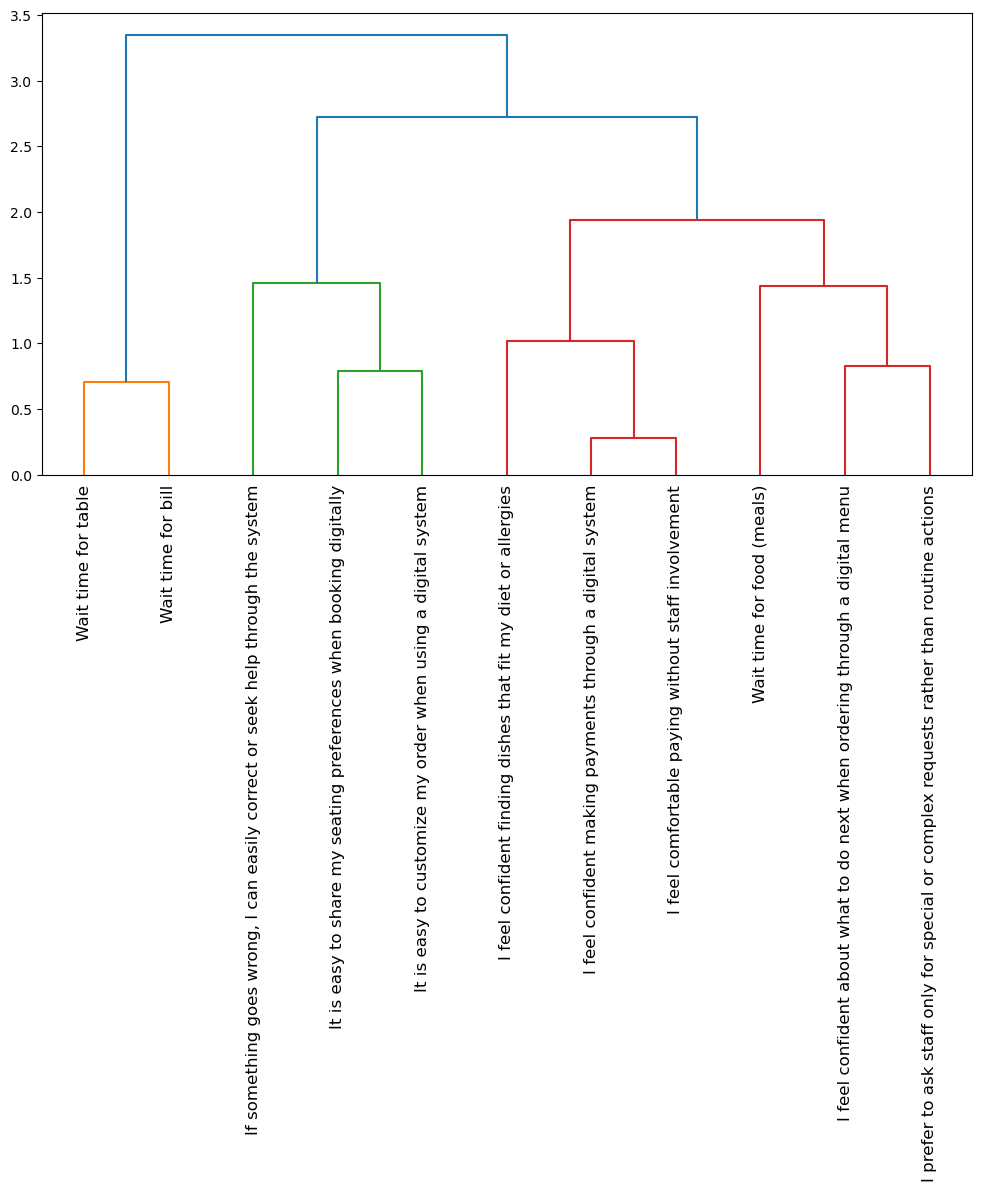

In [20]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

distance = 1 - corr
link = sch.linkage(distance, method='ward')

plt.figure(figsize=(12, 6))
sch.dendrogram(link, labels=corr.columns, leaf_rotation=90)
plt.tight_layout()
plt.show()


In [21]:
# import pingouin as pg
# !pip install factor_analyzer

# pcorr = pg.compute_polychoric(df)[0]




In [22]:
# pip install pingouin


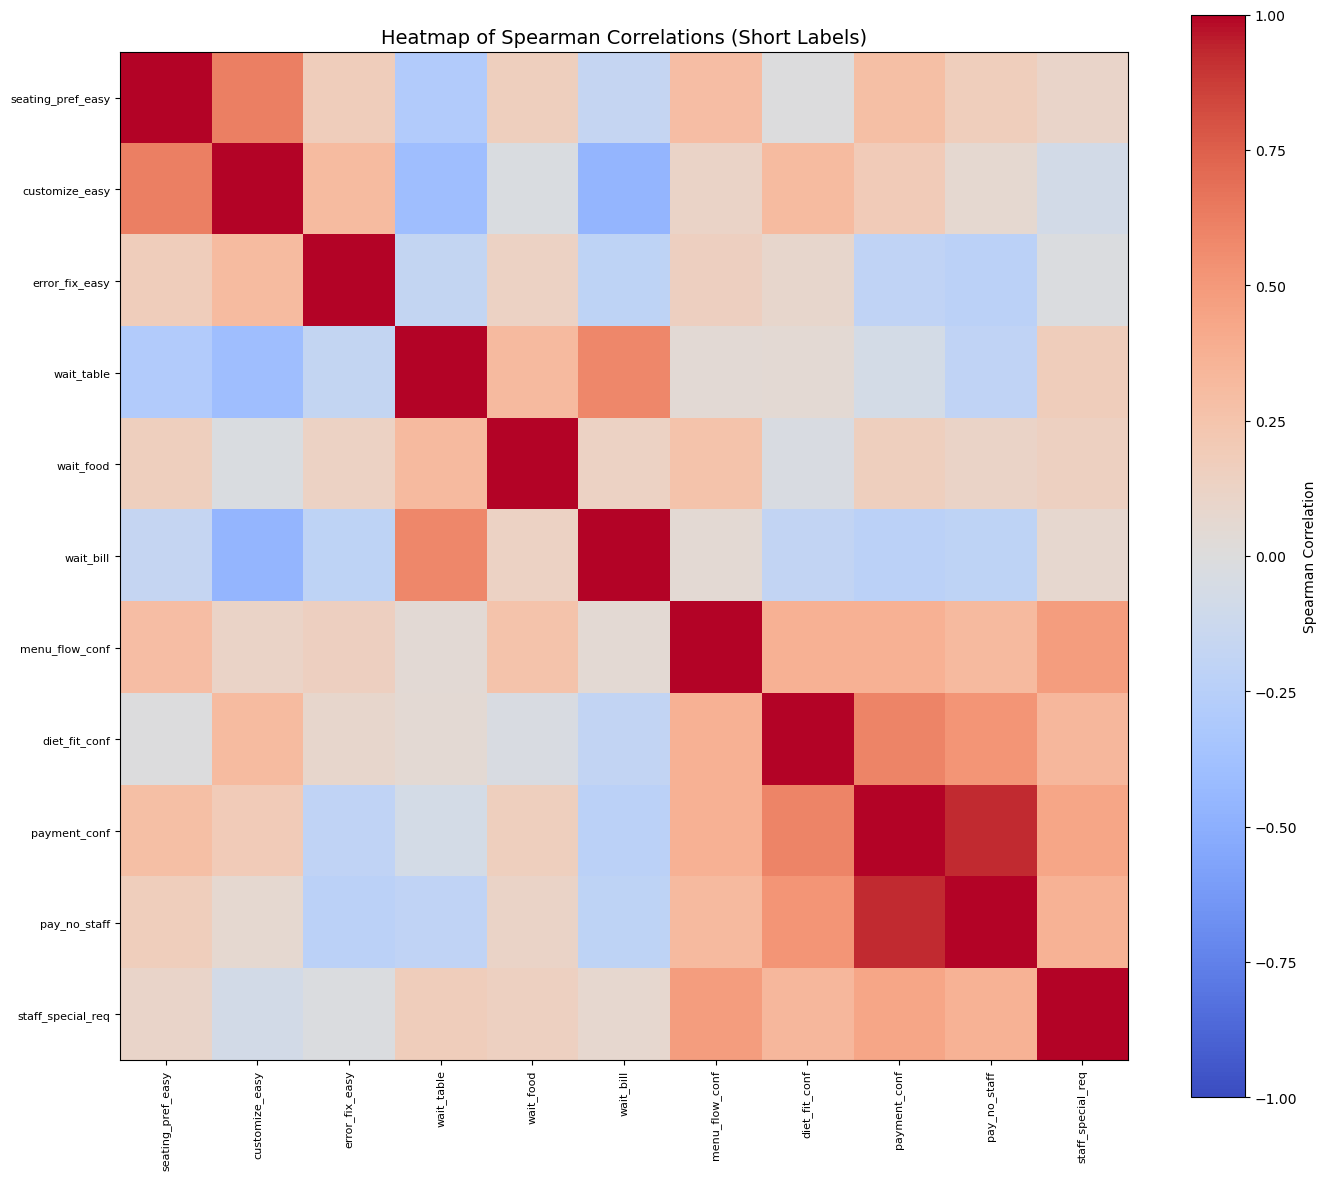

In [23]:
# Create a dictionary mapping long question text → short labels
label_map = {
    "It is easy to share my seating preferences when booking digitally": "seating_pref_easy",
    "It is easy to customize my order when using a digital system": "customize_easy",
    "If something goes wrong, I can easily correct or seek help through the system": "error_fix_easy",
    "Wait time for table": "wait_table",
    "Wait time for food (meals)": "wait_food",
    "Wait time for bill": "wait_bill",
    "I feel confident about what to do next when ordering through a digital menu": "menu_flow_conf",
    "I feel confident finding dishes that fit my diet or allergies": "diet_fit_conf",
    "I feel confident making payments through a digital system": "payment_conf",
    "I feel comfortable paying without staff involvement": "pay_no_staff",
    "I prefer to ask staff only for special or complex requests rather than routine actions": "staff_special_req"
}


corr_short = corr.rename(index=label_map, columns=label_map)
corr_short


plt.figure(figsize=(14, 12))

plt.imshow(corr_short, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label="Spearman Correlation")

# Set axis labels
plt.xticks(np.arange(len(corr_short.columns)), corr_short.columns, rotation=90, fontsize=8)
plt.yticks(np.arange(len(corr_short.index)), corr_short.index, fontsize=8)

plt.title("Heatmap of Spearman Correlations (Short Labels)", fontsize=14)
plt.tight_layout()
plt.show()


In [24]:
# # df
# likert_map = {
#     "strongly disagree": 1,
#     "disagree": 2,
#     "slightly disagree": 3,
#     "slightly agree": 4,
#     "agree": 5,
#     "strongly agree": 6
# }

# for col in label_map:
#     df[col] = df[col].astype(str).str.lower().map(likert_map)


In [25]:
df[likert_cols]

,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,6.0,6.0,4.0,4.0,2.0,5.0,6.0,6.0,6.0,6.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
57,NaN,5.0,NaN,3.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0
58,5.0,5.0,4.0,3.0,5.0,2.0,5.0,4.0,4.0,3.0,5.0
59,3.0,4.0,3.0,5.0,3.0,3.0,6.0,6.0,6.0,6.0,6.0
60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
likert_cols

['It is easy to share my seating preferences when booking digitally',
 'It is easy to customize my order when using a digital system',
 'If something goes wrong, I can easily correct or seek help through the system',
 'Wait time for table',
 'Wait time for food (meals)',
 'Wait time for bill',
 'I feel confident about what to do next when ordering through a digital menu',
 'I feel confident finding dishes that fit my diet or allergies',
 'I feel confident making payments through a digital system',
 'I feel comfortable paying without staff involvement',
 'I prefer to ask staff only for special or complex requests rather than routine actions']

In [27]:
import pingouin as pg

# digital_cols = [
#     "It is easier to clarify billing or payment questions with a person",
#     "It is easier to get assistance during the meal from human staff than from a digital system",
#     "Human staff are better at judging the right time to bring the next course than digital systems",
#     "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
#     "Being checked on by human staff during the meal makes the experience feel more personal",
#     "It feels easier to know what to do when a person guides me upon arrival",
#     "Personal interaction with staff at arrival makes the dining experience feel more genuine",
#     "It is easier to explain my dietary preferences or special needs to a person",
#     "I feel more comfortable communicating personal or dietary needs to a person than through a digital device",
#     "It is easier to ask follow-up questions about dishes when speaking to a person",
#     "I feel reassured when a person confirms my customized order verbally",
#     "It is easier to change or adjust my order when interacting with human staff",
#     "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",
#     "When a digital system fails, having human staff as a fallback makes me feel supported",
#     "I like having the option of human assistance while using a digital system"
# ]

# OPTIONAL: check that all names actually exist in df
missing = [c for c in likert_cols if c not in df.columns]
print("Missing:", missing)  # should be [] before proceeding

# Now compute alpha (assuming these columns are already numeric 1–6)
alpha, ci = pg.cronbach_alpha(data=df[likert_cols])
print("Red Alpha:", alpha)
print("95% CI:", ci)



Missing: []
Red Alpha: 0.3915836174287789
95% CI: [0.14  0.594]


In [28]:
import pingouin as pg

def cronbach_alpha_for(df, cols):
    """
    df   = your dataframe
    cols = list of column names for the construct
    """
    data = df[cols].dropna()
    alpha, ci = pg.cronbach_alpha(data)
    print(f"Cronbach's alpha for {cols}: {alpha:.3f}")
    print(f"95% CI: {ci}")
    return alpha


In [29]:
Digital_Ordering_waittime = [
"Wait time for table",
"Wait time for bill",   
]

cronbach_alpha_for(df, Digital_Ordering_waittime)


Cronbach's alpha for ['Wait time for table', 'Wait time for bill']: 0.718
95% CI: [0.334 0.88 ]


0.7176616915422886

In [30]:
# try booking error recovery with and without double baralled

#Communication & Dietary Comfort
Booking_Error_Recovery_Menu_Personalization = [
"If something goes wrong, I can easily correct or seek help through the system",
"It is easy to share my seating preferences when booking digitally",
"It is easy to customize my order when using a digital system"
]

cronbach_alpha_for(df, Booking_Error_Recovery_Menu_Personalization)


Cronbach's alpha for ['If something goes wrong, I can easily correct or seek help through the system', 'It is easy to share my seating preferences when booking digitally', 'It is easy to customize my order when using a digital system']: 0.683
95% CI: [0.32  0.868]


0.683431952662722

In [31]:
# let us just keep the below two items just for one to one corelation analysis with age and voice based systems

# emphasize and ask about in the interview question

#"I feel confident finding dishes that fit my diet or allergies", ( double baralled)
#"I prefer to ask staff only for special or complex requests rather than routine actions" ( double baralled)



#Treat them as standalone outcome indicators beacause they do not fit anywhere


# "Wait time for food (meals)",
# "I feel confident about what to do next when ordering through a digital menu"

In [32]:
# # try booking error recovery with and without double baralled

# #Communication & Dietary Comfort
# Booking_Error_Recovery_Menu_Personalization1 = [
# "I feel confident finding dishes that fit my diet or allergies",
# "I prefer to ask staff only for special or complex requests rather than routine actions"

# ]

# cronbach_alpha_for(df, Booking_Error_Recovery_Menu_Personalization1)


In [33]:
#Meal-Time Human Assistance
digitial_payment = [
"I feel confident making payments through a digital system",
"I feel comfortable paying without staff involvement",
]

cronbach_alpha_for(df, digitial_payment)


Cronbach's alpha for ['I feel confident making payments through a digital system', 'I feel comfortable paying without staff involvement']: 0.947
95% CI: [0.881 0.977]


0.9473684210526316

In [34]:
#human fallback and trust
ordering_flow = [
"Wait time for food (meals)",
"I feel confident about what to do next when ordering through a digital menu"
]

cronbach_alpha_for(df, ordering_flow)


Cronbach's alpha for ['Wait time for food (meals)', 'I feel confident about what to do next when ordering through a digital menu']: 0.431
95% CI: [-0.316  0.754]


0.43085106382978733

In [35]:
INV_LIKERT_ORDER = {v: k for k, v in LIKERT_ORDER.items()}


# AGREE = ["slightly agree", "agree", "strongly agree"]
# DISAGREE = ["strongly disagree", "disagree", "slightly disagree"]


In [36]:
INV_LIKERT_ORDER

{1: 'strongly disagree',
 2: 'disagree',
 3: 'slightly disagree',
 4: 'slightly agree',
 5: 'agree',
 6: 'strongly agree'}

In [39]:


# vals = list(likert_map.values())
# diffs = np.diff(vals)

# np.all(diffs == diffs[0])


In [40]:
df[likert_cols] 

,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,6.0,6.0,4.0,4.0,2.0,5.0,6.0,6.0,6.0,6.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
57,NaN,5.0,NaN,3.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0
58,5.0,5.0,4.0,3.0,5.0,2.0,5.0,4.0,4.0,3.0,5.0
59,3.0,4.0,3.0,5.0,3.0,3.0,6.0,6.0,6.0,6.0,6.0
60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
# for col in likert_cols:
#     df[col] = (
#         df[col]
#         .astype(str)
#         .str.strip()
#         .str.lower()
#         .map(INV_LIKERT_ORDER)
#     )


df.columns = df.columns.str.strip().str.rstrip(".")



In [42]:
df[likert_cols]

,It is easy to share my seating preferences when booking digitally,It is easy to customize my order when using a digital system,"If something goes wrong, I can easily correct or seek help through the system",Wait time for table,Wait time for food (meals),Wait time for bill,I feel confident about what to do next when ordering through a digital menu,I feel confident finding dishes that fit my diet or allergies,I feel confident making payments through a digital system,I feel comfortable paying without staff involvement,I prefer to ask staff only for special or complex requests rather than routine actions
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.0,6.0,6.0,4.0,4.0,2.0,5.0,6.0,6.0,6.0,6.0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
57,NaN,5.0,NaN,3.0,3.0,2.0,4.0,5.0,5.0,5.0,5.0
58,5.0,5.0,4.0,3.0,5.0,2.0,5.0,4.0,4.0,3.0,5.0
59,3.0,4.0,3.0,5.0,3.0,3.0,6.0,6.0,6.0,6.0,6.0
60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [43]:
LIKERT_MAP_NUM_TO_STR = {
    1: "strongly disagree",
    2: "disagree",
    3: "slightly disagree",
    4: "slightly agree",
    5: "agree",
    6: "strongly agree",
}


In [44]:
for col in likert_cols:
    df[col] = (
        pd.to_numeric(df[col], errors="coerce")   # ensure numeric
        .map(LIKERT_MAP_NUM_TO_STR)               # convert to text
    )


In [45]:
# df["I trust human staff to handle payments more accurately than a digital system"].value_counts(dropna=False)


In [46]:
# print(df[likert_cols].head())
# print(df[likert_cols].dtypes)
# 

In [47]:
# df

In [48]:
df['Gender'].value_counts()

Gender
Man                  30
Woman                26
Prefer not to say     2
Name: count, dtype: int64

In [49]:
df['Age band'].value_counts()

Age band
25–34    33
35–44    11
45–54     6
55–64     3
18–24     3
65+       2
Name: count, dtype: int64

In [50]:

age = "Age band"
modality = "When dining at a restaurant, what is your preferred way to place an order?"


In [52]:
AGREE = ["slightly agree", "agree", "strongly agree"]
DISAGREE = ["strongly disagree", "disagree", "slightly disagree"]

def compute_overall_sentiment(df, likert_col):
    # drop NA
    series = df[likert_col].dropna()

    total = series.shape[0]
    agree = series.isin(AGREE).sum()
    disagree = series.isin(DISAGREE).sum()

    agree_pct = agree / total * 100
    disagree_pct = disagree / total * 100

    return agree, disagree, total, agree_pct, disagree_pct


In [53]:
for q in Digital_Ordering_waittime:
    agree, disagree, total, agree_pct, disagree_pct = compute_overall_sentiment(df, q)
    print(q)
    print(f"Responses: {total}")
    print(f"Agreement: {agree_pct:.1f}%  |  Disagreement: {disagree_pct:.1f}%\n")


Wait time for table
Responses: 23
Agreement: 52.2%  |  Disagreement: 47.8%

Wait time for bill
Responses: 24
Agreement: 45.8%  |  Disagreement: 54.2%



In [54]:
# LIKERT_ORDER_PLOT = [
#     "strongly disagree",
#     "disagree",
#     "slightly disagree",
#     "slightly agree",
#     "agree",
#     "strongly agree",
# ]

# # Make every Likert response lowercase in the entire dataset
# df = df.apply(lambda col: col.str.lower() if col.dtype == "object" else col)


# def plot_checkbox_vs_likert(df, checkbox_col, likert_col,
#                             title_prefix="", figsize=(10,4)):
#     """
#     checkbox_col: multi-select question (exploded or original – we explode inside)
#     likert_col:   one of your Likert question columns
#     """

#     # --- STEP 1: explode checkbox column to long format ---
#     cb = df[checkbox_col].fillna("").str.split(";")
#     cb_exploded = cb.explode().str.strip()
#     cb_exploded = cb_exploded[cb_exploded != ""]   # drop empties

#     df_long = df.loc[cb_exploded.index].copy()
#     df_long["checkbox_cat"] = cb_exploded

#     # --- STEP 2: crosstab checkbox categories x Likert responses (COUNTS) ---
#     ct = pd.crosstab(
#         df_long["checkbox_cat"],
#         df_long[likert_col]
#     )

#     # ensure all Likert categories exist & in right order
#     for resp in LIKERT_ORDER_PLOT:
#         if resp not in ct.columns:
#             ct[resp] = 0
#     ct = ct[LIKERT_ORDER_PLOT]

#     # counts
#     ct_counts = ct.copy()

#     # total across ALL age bands & ALL responses
#     total_n = ct_counts.values.sum()

#     # --- STEP 3: plot COUNTS (like your screenshot) ---
#     ax = ct_counts.plot(
#         kind="barh",
#         stacked=True,
#         figsize=figsize
#     )

#     ax.set_xlabel("Count")
#     ax.set_ylabel(checkbox_col)
#     ax.set_title(f"{title_prefix}{likert_col}")

#     # --- STEP 4: add GLOBAL % labels on each segment ---
#     for i, count_row in enumerate(ct_counts.values):
#         cum = 0
#         for count in count_row:
#             if count > 0:
#                 pct_global = count / total_n * 100  # <-- across all age groups
#                 ax.text(
#                     cum + count / 2,
#                     i,
#                     f"{pct_global:.1f}%",  # e.g. "2.3%"
#                     ha="center", va="center",
#                     fontsize=8,
#                     color="white" if count > 3 else "black"
#                 )
#             cum += count

#     ax.legend(
#         title="Response",
#         bbox_to_anchor=(1.15, 1),
#         loc="upper left"
#     )

#     plt.tight_layout()
#     plt.show()



LIKERT_ORDER_PLOT = [
    "strongly disagree",
    "disagree",
    "slightly disagree",
    "slightly agree",
    "agree",
    "strongly agree",
]

AGREE = ["slightly agree", "agree", "strongly agree"]
DISAGREE = ["strongly disagree", "disagree", "slightly disagree"]

df = df.apply(lambda col: col.str.lower() if col.dtype == "object" else col)


def plot_checkbox_vs_likert(df, checkbox_col, likert_col,
                            title_prefix="", figsize=(10,4)):

    # --- STEP 1: explode checkbox column to long format ---
    cb = df[checkbox_col].fillna("").str.split(";")
    cb_exploded = cb.explode().str.strip()
    cb_exploded = cb_exploded[cb_exploded != ""]
    df_long = df.loc[cb_exploded.index].copy()
    df_long["checkbox_cat"] = cb_exploded

    # --- STEP 2: crosstab (COUNTS) ---
    ct = pd.crosstab(
        df_long["checkbox_cat"],
        df_long[likert_col]
    )

    # ensure all Likert categories exist & in right order
    for resp in LIKERT_ORDER_PLOT:
        if resp not in ct.columns:
            ct[resp] = 0
    ct = ct[LIKERT_ORDER_PLOT]

    ct_counts = ct.copy()
    total_n_cells = ct_counts.values.sum()   # for global % on segments

    # --- STEP 2b: overall agreement / disagreement for THIS QUESTION ---
    s = df[likert_col].dropna()              # exclude NA
    total_valid = s.shape[0]
    agree_n = s.isin(AGREE).sum()
    disagree_n = s.isin(DISAGREE).sum()

    agree_pct = agree_n / total_valid * 100 if total_valid > 0 else 0
    disagree_pct = disagree_n / total_valid * 100 if total_valid > 0 else 0

    summary_text = (
        f"N = {total_valid}\n"
        f"Agree: {agree_pct:.1f}% (n={agree_n})\n"
        f"Disagree: {disagree_pct:.1f}% (n={disagree_n})"
    )

    # --- STEP 3: plot COUNTS (like your screenshot) ---
    ax = ct_counts.plot(
        kind="barh",
        stacked=True,
        figsize=figsize
    )

    ax.set_xlabel("Count")
    ax.set_ylabel(checkbox_col)
    ax.set_title(f"{title_prefix}{likert_col}")

    # global-% labels on each segment (optional – this is what you had)
    for i, row in enumerate(ct_counts.values):
        cum = 0
        for count in row:
            if count > 0:
                pct_global = count / total_n_cells * 100
                ax.text(
                    cum + count / 2,
                    i,
                    f"{pct_global:.1f}%",
                    ha="center", va="center",
                    fontsize=8,
                    color="white" if count > 3 else "black"
                )
            cum += count

    # legend outside
    ax.legend(
        title="Response",
        bbox_to_anchor=(1.35, 1),
        loc="upper left"
    )

    # --- STEP 4: add summary box BESIDE the plot ---
    ax.text(
        1.02, 0.3,                   # x, y in axes coords (just outside right)
        summary_text,
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray")
    )

    plt.tight_layout()
    plt.show()


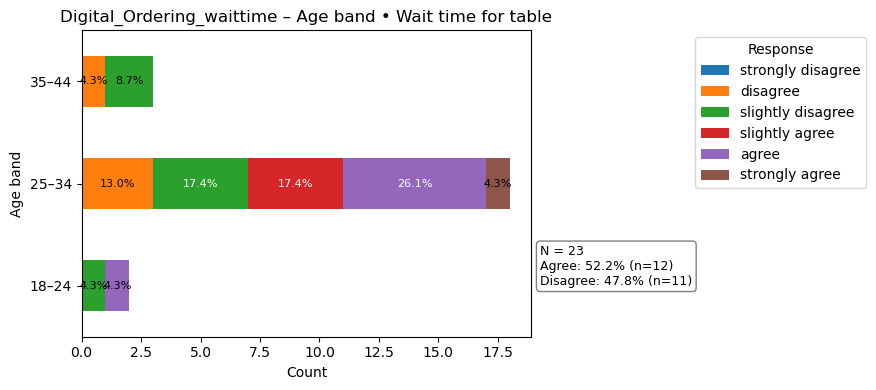

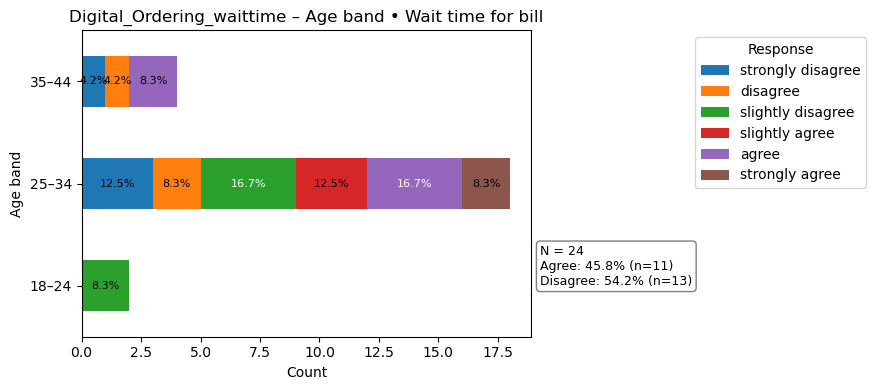

In [55]:
# Dining_frequency = "Dining frequency ( Select all that applies)"

# age = "Age band"
# Dining_frequency = "Dining frequency ( Select all that applies)"
# Typical_group_size = "Typical group size while dining (Select all that applies)"
# Type_of_restaurant = "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)"


# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}



Digital_Ordering_waittime = [
"Wait time for table",
"Wait time for bill",   
]

# arrival_cols = [
#     "Upon arrival, I prefer to interact with a human staff member rather than a digital system",
#     "It feels easier to know what to do when a person guides me upon arrival",
#     "Personal interaction with staff at arrival makes the dining experience feel more genuine"
# ]

# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in Digital_Ordering_waittime:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Digital_Ordering_waittime – {demo_label} • "
        )



# Age band
# 25–34    33
# 35–44    11
# 45–54     6
# 55–64     3
# 18–24     3
# 65+       2
# Name: count, dtype: int64

# Most people strongly agree that Upon arrival, I prefer to interact with a human staff member rather than a digital system and everyone from 18-24 agree they want this


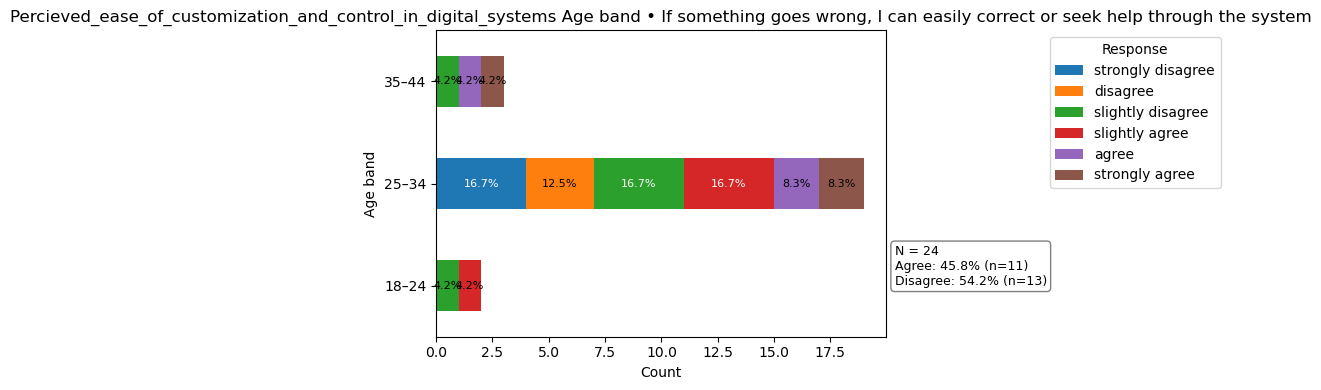

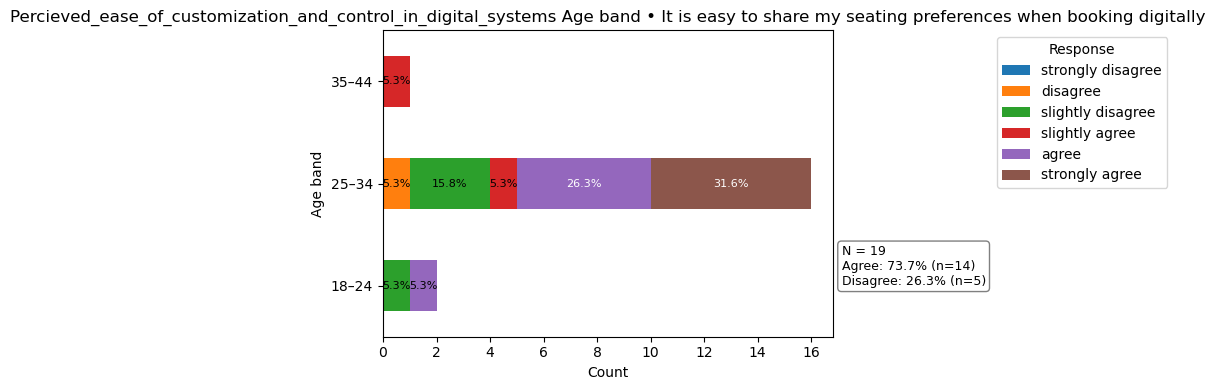

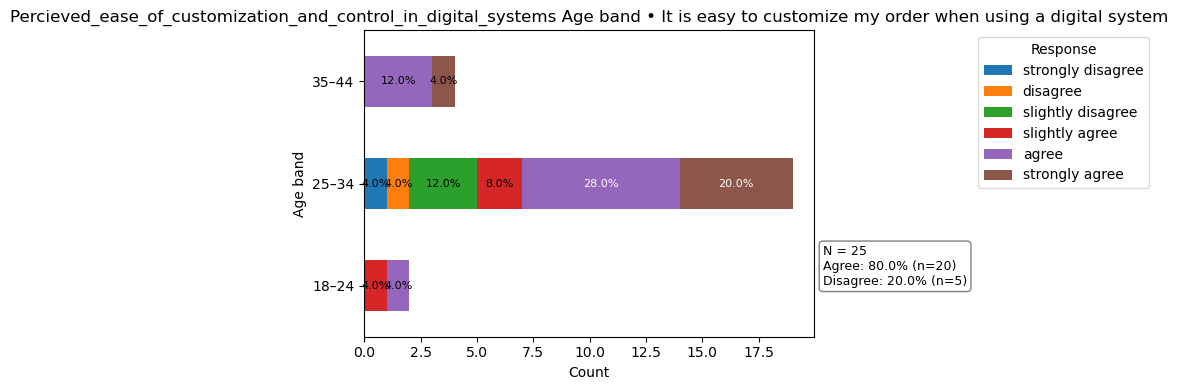

In [56]:


# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band",
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}



Percieved_ease_of_customization_and_control_in_digital_systems = [
"If something goes wrong, I can easily correct or seek help through the system",
"It is easy to share my seating preferences when booking digitally",
"It is easy to customize my order when using a digital system"]
# "I feel confident finding dishes that fit my diet or allergies"





# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in Percieved_ease_of_customization_and_control_in_digital_systems:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Percieved_ease_of_customization_and_control_in_digital_systems {demo_label} • "
        )

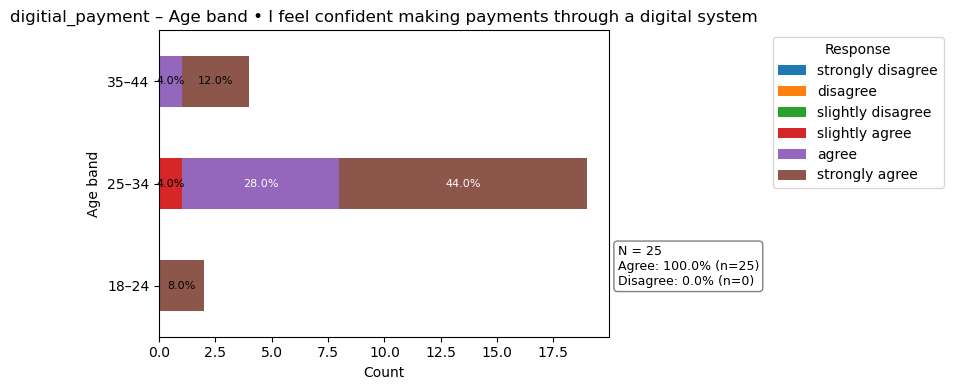

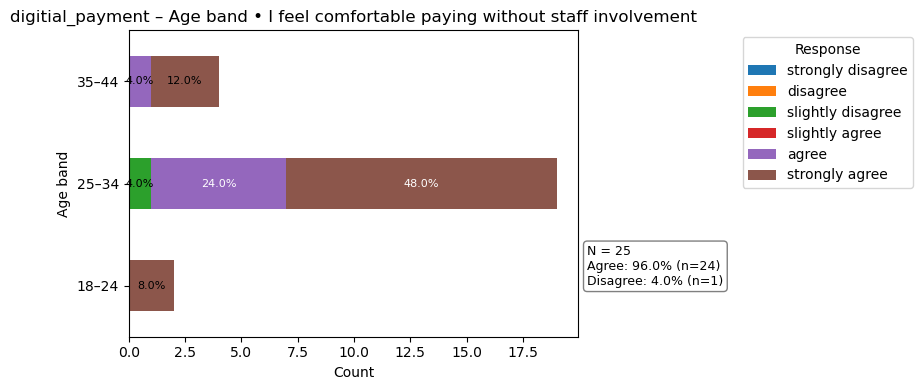

In [57]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN
digitial_payment = [
"I feel confident making payments through a digital system",
"I feel comfortable paying without staff involvement",
]

# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in digitial_payment:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"digitial_payment – {demo_label} • "
        )

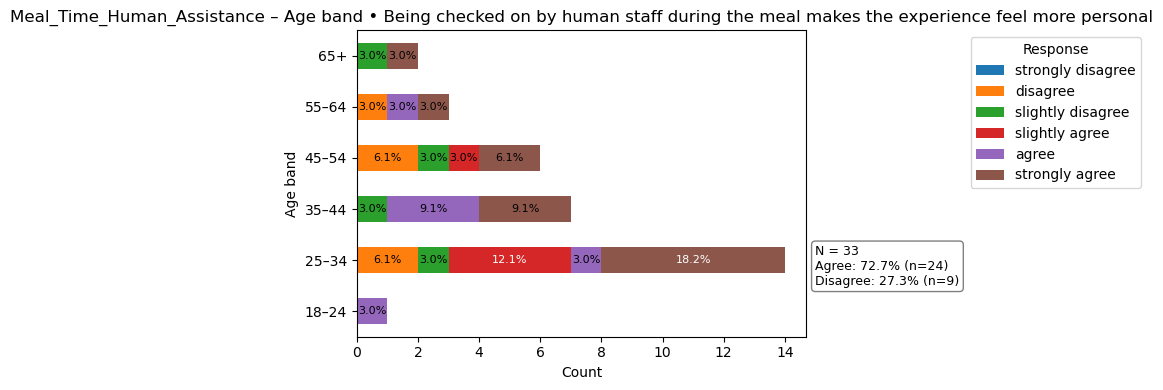

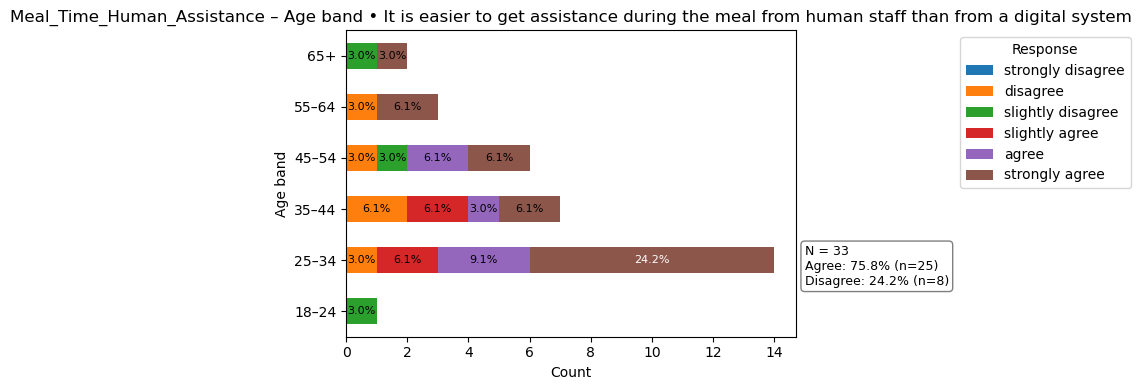

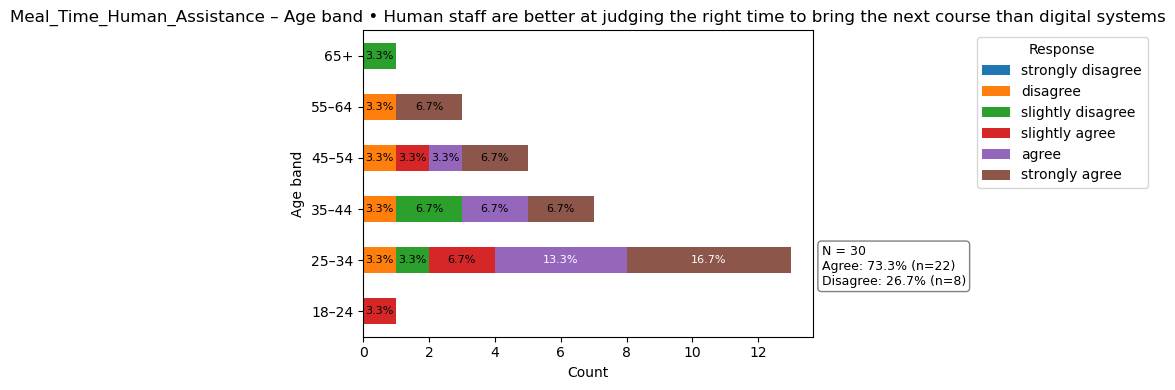

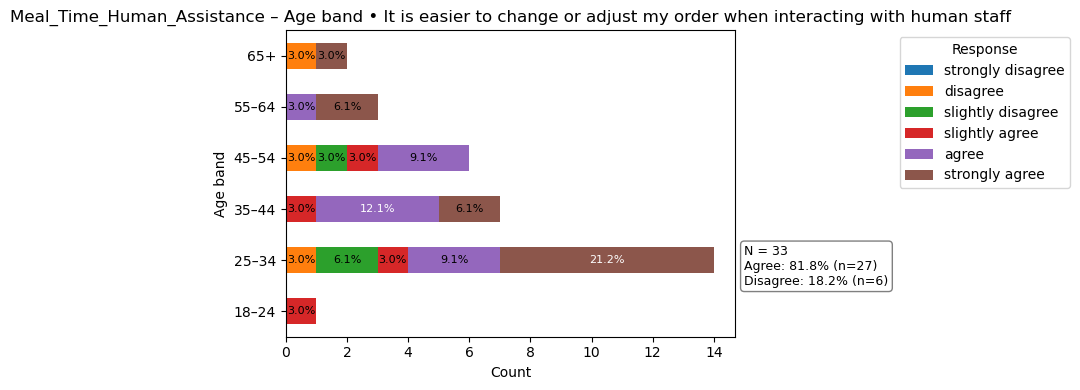

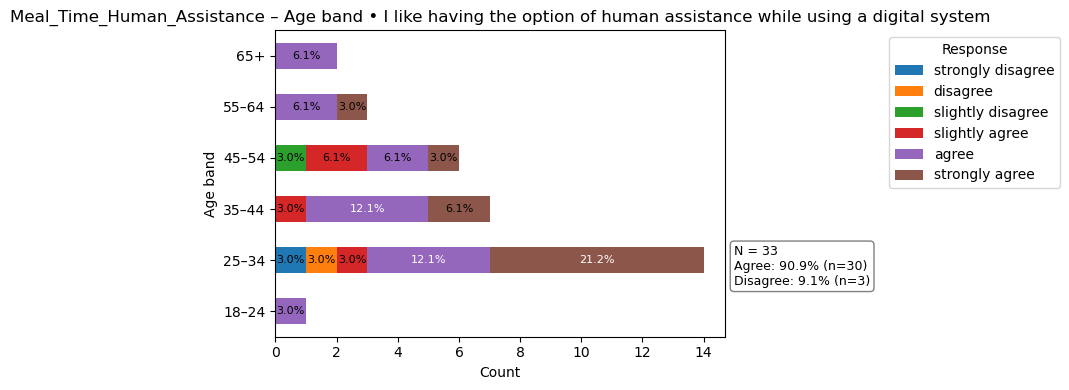

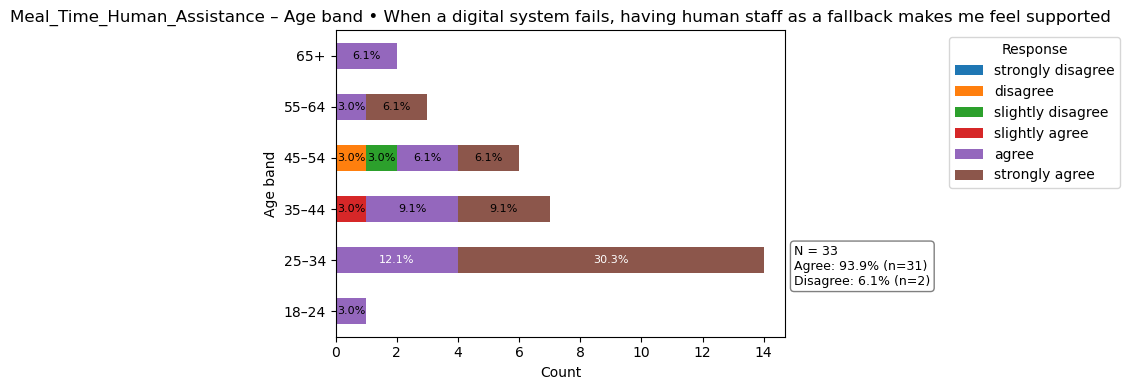

In [70]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN
Meal_Time_Human_Assistance = [
Wait time for food

]

# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in Meal_Time_Human_Assistance:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"Meal_Time_Human_Assistance – {demo_label} • "
        )

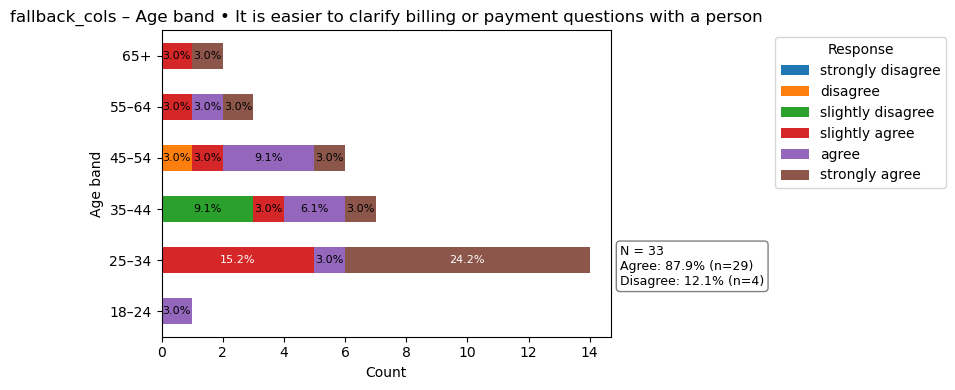

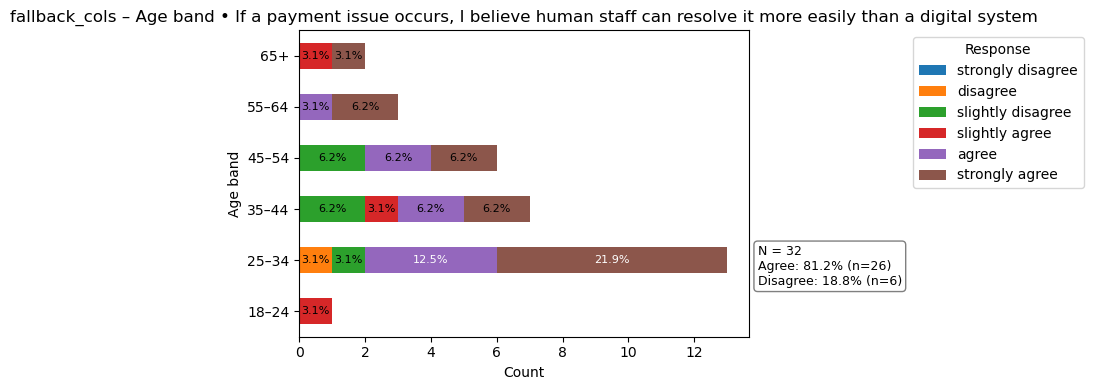

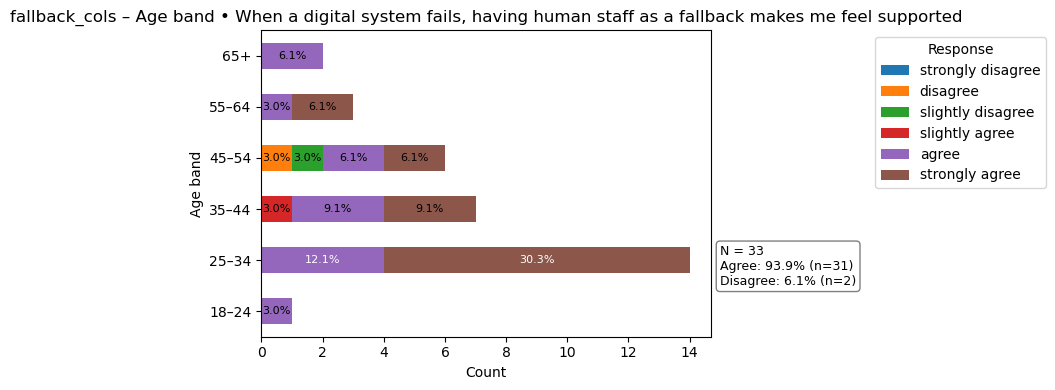

In [71]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN
fallback_cols = [
    "It is easier to clarify billing or payment questions with a person",
    "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system",
    "When a digital system fails, having human staff as a fallback makes me feel supported",
]


# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in fallback_cols:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"fallback_cols – {demo_label} • "
        )

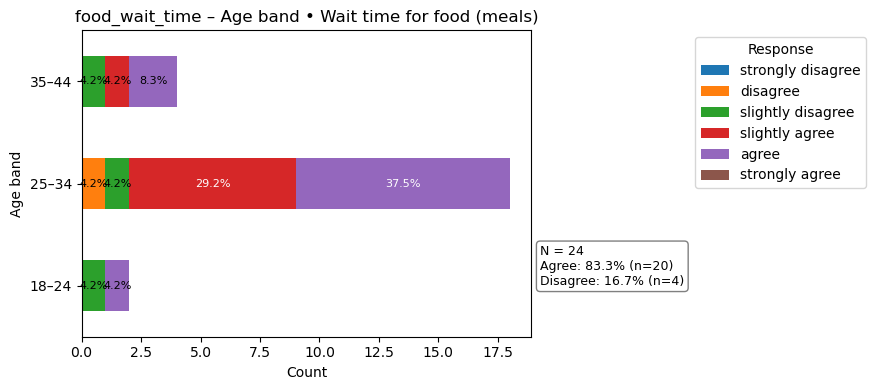

In [58]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN

food_wait_time = [
"Wait time for food (meals)"
]


# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in food_wait_time:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"food_wait_time – {demo_label} • "
        )

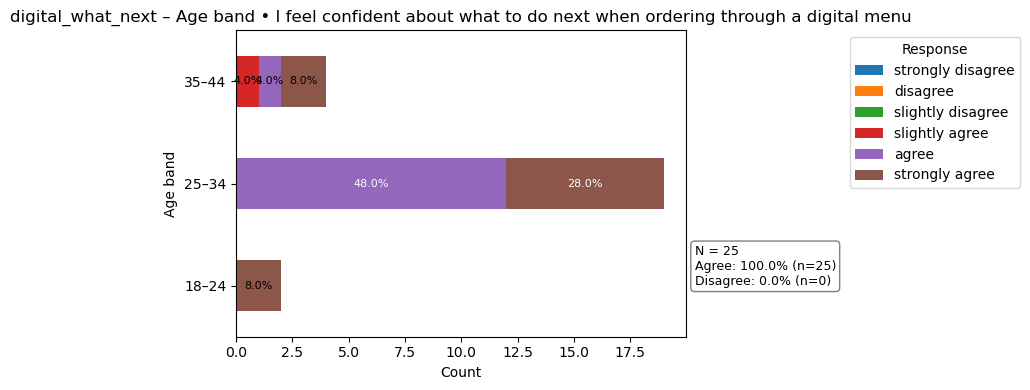

In [59]:
# Your demographic checkbox / category columns
demographic_checkboxes = {
    "Age band": "Age band"
    # "Dining frequency ( Select all that applies)": "Dining frequency",
    # "Typical group size while dining (Select all that applies)": "Typical group size",
    # "Which type of restaurant setting do you most often visit?\xa0 (Select all that applies)": "Restaurant setting",
}

# Despite imperfect wording (which is comparitive), people interpreted these three questions in a very consistent way. Ofcourse the definition of consistency
# here is subjective to interpretation...this is a limitation

# 3) Human interaction during the MEAL – HUMAN

digital_what_next = [
"I feel confident about what to do next when ordering through a digital menu"
]

# Dynamic loop for all demographics × all Likert items
for checkbox_col, demo_label in demographic_checkboxes.items():
    for q in digital_what_next:
        plot_checkbox_vs_likert(
            df,
            checkbox_col=checkbox_col,
            likert_col=q,
            title_prefix=f"digital_what_next – {demo_label} • "
        )

In [76]:
# # Create a dictionary mapping long question text → short labels
# label_map = {
#     "Upon arrival, I prefer to interact with a human staff member rather than a digital system": "Arrival_Pref",
#     "It feels easier to know what to do when a person guides me upon arrival": "Guided_Ease",
#     "Personal interaction with staff at arrival makes the dining experience feel more genuine": "Arrival_Genuine",
#     "It is easier to understand menu items when a person explains them": "Menu_Understand",
#     "I like when a staff member helps me explore the menu or suggests dishes": "Menu_Help",
#     "I trust human staff more than a digital system to provide accurate menu information": "Menu_Trust",
#     "I enjoy hearing about dishes from a person rather than reading them on a screen": "Menu_Hear",
#     "When a digital system fails, having human staff as a fallback makes me feel supported": "Fallback_Support",
#     "I like having the option of human assistance while using a digital system": "Option_Help",
#     "It is easier to explain my dietary preferences or special needs to a person": "Dietary_Explain",
#     "It is easier to change or adjust my order when interacting with human staff": "Order_Adjust",
#     "I feel reassured when a person confirms my customized order verbally": "Order_Reassured",
#     "It is easier to get assistance during the meal from human staff than from a digital system": "Meal_Assist",
#     "Human staff are better at judging the right time to bring the next course than digital systems": "Timing_Judgement",
#     "I feel more comfortable communicating personal or dietary needs to a person than through a digital device": "Comfort_Dietary",
#     "Being checked on by human staff during the meal makes the experience feel more personal": "Checked_On",
#     "It is easier to ask follow-up questions about dishes when speaking to a person": "FollowUp_Questions",
#     "I trust human staff to handle payments more accurately than a digital system": "Pay_Trust",
#     "It is easier to clarify billing or payment questions with a person": "Pay_Clarify",
#     "If a payment issue occurs, I believe human staff can resolve it more easily than a digital system": "Pay_Issue",
#     "It is easier to understand the bill when a person explains what I am paying for": "Bill_Understand",
#     "Having a person handle payment makes me feel more confident and reassured about the transaction": "Pay_Confident",
#     "I feel more in control of my payment when interacting with a person rather than a digital system": "Pay_Control"
# }

# corr_short = corr.rename(index=label_map, columns=label_map)
# corr_short


# plt.figure(figsize=(14, 12))

# plt.imshow(corr_short, cmap='coolwarm', vmin=-1, vmax=1)
# plt.colorbar(label="Spearman Correlation")

# # Set axis labels
# plt.xticks(np.arange(len(corr_short.columns)), corr_short.columns, rotation=90, fontsize=8)
# plt.yticks(np.arange(len(corr_short.index)), corr_short.index, fontsize=8)

# plt.title("Heatmap of Spearman Correlations (Short Labels)", fontsize=14)
# plt.tight_layout()
# plt.show()



from scipy.stats import binomtest, kruskal


# clean text (you already mostly do this)
df_clean = df.copy()
for col in df_clean.columns:
    if df_clean[col].dtype == "object":
        df_clean[col] = df_clean[col].str.strip().str.lower()




def overall_agree_disagree(row, cols):
    vals = row[cols].dropna()
    if vals.empty:
        return np.nan
    
    agree_count = vals.isin(AGREE).sum()
    disagree_count = vals.isin(DISAGREE).sum()
    
    if (agree_count == 0) and (disagree_count == 0):
        return np.nan  # all neutral
    if agree_count > disagree_count:
        return "agree"
    elif disagree_count > agree_count:
        return "disagree"
    else:
        return np.nan  # tie -> drop from test


df_clean["arrival_overall"] = df_clean.apply(
    overall_agree_disagree, cols=arrival_cols, axis=1
)

# counts
arrival_counts = df_clean["arrival_overall"].value_counts(dropna=True)
n_agree = int(arrival_counts.get("agree", 0))
n_disagree = int(arrival_counts.get("disagree", 0))
n_total = n_agree + n_disagree

print("Agree:", n_agree, "Disagree:", n_disagree, "Total used:", n_total)

# one-sided binomial test: H0: p_agree <= 0.5 vs H1: p_agree > 0.5
if n_total > 0:
    res = binomtest(n_agree, n_total, p=0.5, alternative="greater")
    print(res)
else:
    print("Not enough data (no agree/disagree cases).")


Agree: 32 Disagree: 1 Total used: 33
BinomTestResult(k=32, n=33, alternative='greater', statistic=0.9696969696969697, pvalue=3.958120942115784e-09)


In [82]:
# 2. Make sure they are numeric Likert codes (e.g. 1–6)
# If you already coded them earlier, you can skip this part.
LIKERT_MAP = {
    "strongly disagree": 1,
    "disagree": 2,
    "slightly disagree": 3,
    "slightly agree": 4,
    "agree": 5,
    "strongly agree": 6,
}

for col in arrival_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.lower()
        .map(LIKERT_MAP)
    )

# 3. Sum the three items into a construct score (still ordinal, just more levels)
df["arrival_score"] = df[arrival_cols].sum(axis=1)

In [83]:
df["arrival_score"]

0     12.0
1      0.0
2     18.0
3     18.0
4      0.0
      ... 
57     0.0
58     0.0
59     0.0
60    14.0
61     0.0
Name: arrival_score, Length: 62, dtype: float64

In [84]:
# Define the age order EXACTLY as it appears in your data
age_order = pd.CategoricalDtype(
    categories=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65+",
    ],
    ordered=True,
)

df["age_band_ord"] = df["Age band"].astype(age_order)

# Convert ordered categories to integer codes 1..6
# 18-24 -> 0, 25-34 -> 1, ... so add 1 to start from 1
df["age_code"] = df["age_band_ord"].cat.codes + 1


In [89]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.api as sm

# 1. Dependent variable as ordered categories (e.g. 1–6)
y = data["likert_code"]   # already numeric ordered codes

# 2. Explanatory variables WITHOUT constant
X = data[["age_code"]]    # or data["age_code"] if it's a Series

# 3. Fit the ordinal logistic regression
model = OrderedModel(
    y,
    X,
    distr="logit"   # or "probit"
)

res = model.fit(method="bfgs", disp=False)

print(res.summary())


KeyError: 'likert_code'

In [90]:
from scipy.stats import kruskal


# Type 3
# 	1. Based on plot 4 and 5 there exists a small percentage of population that do not feel reassured when humans reconfirm customize orders
# 	H0 = people across all age bands feel equally reassured by order conformation from humans
# 	H1 = People across age bands are not equally reassured by order confirmation from humans
	
# 	H0 = People across all age bands find it easy to customize the order when speaking to a human
# 	H1= People across different age bands do not feel equally reassured for adjusting their order when speaking with a human staff


# meal_assistance = [
#     "Being checked on by human staff during the meal makes the experience feel more personal",
#     "It is easier to get assistance during the meal from human staff than from a digital system",
#     "Human staff are better at judging the right time to bring the next course than digital systems",
#     "It is easier to change or adjust my order when interacting with human staff",
#     "I feel reassured when a person confirms my customized order verbally"
# ]



def kruskal_by_age(df, item_col,
                   age_col="Age band",
                   age_order=("18-24", "25-34", "35-44", "45-54", "55-64", "65+"),
                   min_n_per_group=2):
    """
    Kruskal–Wallis test of a single Likert item across ordered age bands.
    df        : pandas DataFrame
    item_col  : column name of the Likert item (string)
    age_col   : column with age bands
    age_order : order of age bands
    min_n_per_group : minimum N per age band to include in test
    """
    groups = []
    labels = []

    for age in age_order:
        mask = df[age_col] == age
        if not mask.any():
            continue

        # Get raw values for that age
        vals_raw = df.loc[mask, item_col].dropna()

        if vals_raw.empty:
            continue

        # Map Likert text → numeric
        vals_num = (
            vals_raw.astype(str)
                    .str.strip()
                    .str.lower()
                    .map(LIKERT_MAP)
        )

        vals_num = vals_num.dropna()

        if len(vals_num) >= min_n_per_group:
            groups.append(vals_num.values)
            labels.append(age)

    print(f"\nItem: {item_col}")
    print("Age groups included and Ns:")
    for lab, g in zip(labels, groups):
        print(f"  {lab}: N = {len(g)}")

    if len(groups) < 2:
        print("Not enough age groups with data to run Kruskal–Wallis.")
        return None

    stat, p = kruskal(*groups)
    print(f"\nKruskal–Wallis H = {stat:.3f}, p = {p:.4f}")
    if p < 0.05:
        print("→ Reject H₀: distributions differ across age bands.")
    else:
        print("→ Fail to reject H₀: no clear age effect detected.")

    return stat, p



In [93]:

Item4 = "It is easier to change or adjust my order when interacting with human staff"                                                   
item5 = "I feel reassured when a person confirms my customized order verbally"

kruskal_by_age(df, Item4)
kruskal_by_age(df, item5)


NameError: name 'item4' is not defined